### Step 1: Import Libraries and Load Dataset

In [4]:
# استيراد المكتبات الأساسية
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

# تحميل ملفات CSV
train_df = pd.read_csv('./sign_mnist_train/sign_mnist_train.csv')
test_df = pd.read_csv('./sign_mnist_test/sign_mnist_test.csv')

# عرض بعض البيانات
print("Train sample:")
print(train_df.head())
print("\nTest sample:")
print(test_df.head())
print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train sample:
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206     

### Step 2: Prepare Images and Labels

In [5]:
# فصل الـ labels عن البيانات
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# إعادة تشكيل الصور 28x28x1
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# تحويل الـ labels إلى one-hot encoding
y_train_cat = to_categorical(y_train, num_classes=26)
y_test_cat = to_categorical(y_test, num_classes=26)

# التحقق من الأشكال
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (27455, 28, 28, 1)
X_test shape: (7172, 28, 28, 1)


### Step 3: Visualize Sample Images

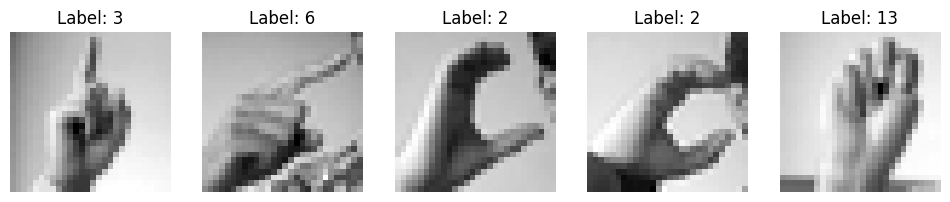

In [6]:
plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


### Step 4: Data Augmentation

In [7]:
datagen = ImageDataGenerator(
    rotation_range=10,      # دوران خفيف فقط
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=False
)

datagen.fit(X_train)


### Step 5: Build Enhanced CNN Model

In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(26, activation='softmax'))

model.summary()


c:\Users\HP\Downloads\Deep Learning Labs\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Compile Model

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


### Step 7: Train Model with Data Augmentation

In [10]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_test, y_test_cat),
    steps_per_epoch=len(X_train)//64,
    epochs=15
)


Epoch 1/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.3380 - loss: 2.1573 - val_accuracy: 0.7524 - val_loss: 0.8299
Epoch 2/15
  1/428 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5156 - loss: 1.3950

c:\Users\HP\Downloads\Deep Learning Labs\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


428/428 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5156 - loss: 1.3950 - val_accuracy: 0.7606 - val_loss: 0.8240
Epoch 3/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.6557 - loss: 1.0183 - val_accuracy: 0.8539 - val_loss: 0.4700
Epoch 4/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7969 - loss: 0.6879 - val_accuracy: 0.8448 - val_loss: 0.4808
Epoch 5/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.7548 - loss: 0.7044 - val_accuracy: 0.9002 - val_loss: 0.3087
Epoch 6/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8125 - loss: 0.5752 - val_accuracy: 0.9055 - val_loss: 0.3014
Epoch 7/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8113 - loss: 0.5451 - val_accuracy: 0.9359 - val_loss: 0.2409
Epoch 8/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8281 - loss: 0.4642 - val_accuracy: 0.9352 - val_loss: 0.2396
Epoch 9/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8430 - loss: 0.4524 - val_accuracy: 0.941

### Step 8: Plot Training History

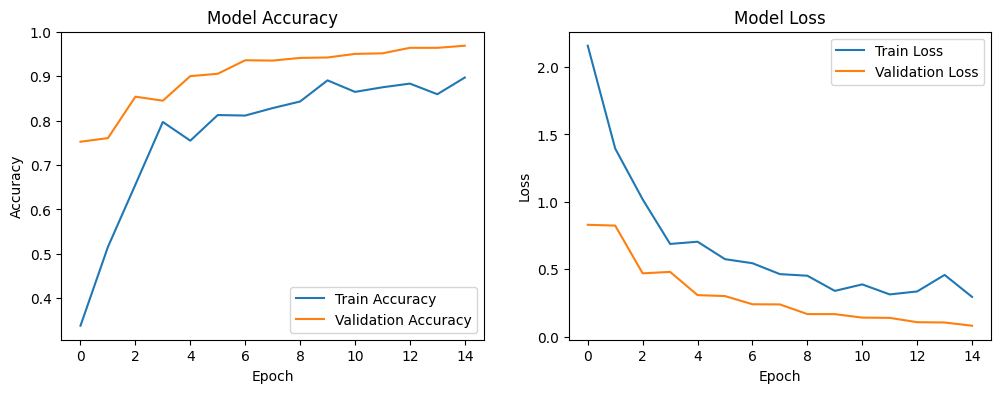

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Step 9: Test Predictions on Random Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


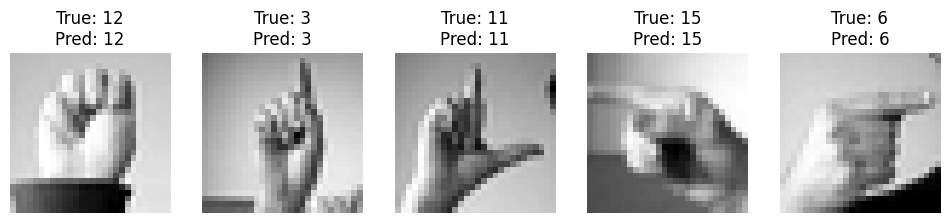

In [16]:
indices = random.sample(range(X_test.shape[0]), 5)
sample_images = X_test[indices]
sample_labels = y_test[indices]

predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(sample_images[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {sample_labels[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.show()
